#0. Introduzione
In questo notebook vengono addestrati e valutati diversi modelli di classificazione, con l’obiettivo di identificare quello più efficace nella predizione delle classi target in uno studio sui disturbi neuropsichiatrici, con particolare attenzione alla classificazione della mallattia di Alzheimer. L’obiettivo principale è massimizzare la balanced accuracy, in quanto il dataset presenta un marcato sbilanciamento tra le classi.

La balanced accuracy, in particolare, calcola la media del recall per ogni classe, dando lo stesso peso a tutte, anche se sono sbilanciate.

Il dataset è già stato oggetto di analisi esplorativa e preprocessamento in una fase precedente, pertanto le sue caratteristiche non vengono qui descritte nel dettaglio.

Tutte le feature disponibili vengono impiegate per l’addestramento dei modelli. Al fine di garantire una validazione corretta e priva di data leakage tra i fold, è stata costruita una pipeline di preprocessing che include: imputazione dei valori mancanti, codifica delle variabili categoriche e normalizzazione delle variabili numeriche.

Il codice è progettato per essere flessibile e adattabile sia a problemi di classificazione binaria che multiclasse.

#1. Caricamento librerie
In questa sezione sono state caricate tutte le librerie utilizzate.

In [ ]:
# Installazione librerie esterne
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


In [ ]:
# Librerie per la manipolazione dei dati
import pandas as pd
import numpy as np

# Librerie per la visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# Librerie per il preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.pipeline import Pipeline

# Librerie per la selezione e validazione del modello
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Librerie per la valutazione del modello
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    make_scorer
)

# Librerie per modelli di classificazione
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier, RandomForestRegressor
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# Librerie per costruzione pipeline e bilanciamento classi
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

# Librerie per gestione di warnings
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

#2. Definizione funzioni per la pipeline e per la valutazione dei modelli
Nel blocco di codice sottostante vengono definite diverse funzioni e classi utili alla costruzione di una pipeline avanzata per il trattamento di dati supervisionati, focalizzata su imputazione, preprocessing, bilanciamento delle classi e valutazione delle performance del modello.

Una pipeline garantisce che tutte le trasformazioni (imputazione, scaling, encoding, ecc.) vengano eseguite nello stesso ordine e con gli stessi parametri sia durante l’addestramento che durante il test.
Evita errori come applicare lo scaling ai dati di test in modo diverso rispetto al training e calcolare statistiche (es. mediana) su tutto il dataset, introducendo data leakage, ovvero informazioni del test che influenzano il training, causando risultati troppo ottimistici e non realistici.
Con la pipeline tutti i passaggi di preprocessing vengono fittati solo sul training set durante la validazione incrociata, evitando che informazioni del test (o dei fold di validazione) “contaminino” il modello. Ad esempio, i dati mancanti nei fold di validazione o nel test set vengono imputati utilizzando i parametri calcolati solo sul training, anche in ogni fold della cross-validation.

Nello specifico, vengono implementati tre custom transformer per gestire in modo intelligente i valori mancanti:

- **CategoricalESITOImputer**: sostituisce i valori mancanti nelle colonne categoriche (*_ESITO) con la moda (valore più frequente).

- **PGEsitoImputer**: imputa le colonne numeriche (*_PG) in base alla mediana (o media) calcolata per ciascuna categoria associata nella rispettiva colonna _ESITO, preservando così la dipendenza semantica tra le due variabili.

- **IterativePGImputer**: utilizza un approccio avanzato basato su IterativeImputer con regressori Random Forest per stimare i valori mancanti residui nelle colonne *_PG, sfruttando le correlazioni tra le variabili numeriche. Questo step è fondamentale soprattutto durante la validazione incrociata, dove può accadere che, in alcuni fold di training, non siano presenti valori di _PG per certe categorie nella variabile _ESITO. In tali casi, il primo imputatore (PGEsitoImputer) non riesce a calcolare la mediana corrispondente per quella categoria, lasciando dei valori NaN. L’imputazione iterativa sopperisce a queste mancanze, garantendo la completezza del dataset in ogni fold.

Successivamente, il tutto viene organizzato in una pipeline (**build_pipeline**) che include anche:

- Preprocessing (scaling e encoding),
- Bilanciamento delle classi tramite SMOTETomek,
- Classificatore finale.

Infine, la funzione **evaluate_model** consente una valutazione completa del modello, includendo:

- le migliori metriche di cross-validation ottenute durante la ricerca degli iperparametri,
- accuratezza bilanciata, F1-score e ROC AUC sul test set,
- report di classificazione dettagliato e matrice di confusione con heatmap.

Tutte le funzioni sono progettate per essere compatibili sia con compiti di classificazione binaria che multiclasse.

In [ ]:
# Classe per imputare i valori mancanti delle colonne *_PG in base alla mediana
# (o altro metodo) calcolata per ogni categoria nella colonna corrispondente *_ESITO
class PGEsitoImputer(BaseEstimator, TransformerMixin):
    def __init__(self, method='median'):
        self.method = method  # Metodo di aggregazione (es. 'median', 'mean')
        self.fill_values_ = {}  # Dizionario per salvare i valori di imputazione

    def fit(self, X, y=None):
        # Per ogni colonna che finisce con '_PG'
        for col in X.columns:
            if col.endswith('_PG'):
                # Trova la colonna *_ESITO corrispondente
                esito_col = col.replace('_PG', '_ESITO')
                if esito_col in X.columns:
                    # Crea sotto-dataset senza NaN
                    sub = X[[col, esito_col]].dropna()
                    # Calcola l'aggregato (es. mediana) di 'col' per ogni categoria di 'esito_col'
                    agg = sub.groupby(esito_col)[col].agg(self.method)
                    # Salva i valori di imputazione per ogni categoria
                    self.fill_values_[col] = agg
        return self

    def transform(self, X):
        # Verifica che il fit sia stato eseguito
        check_is_fitted(self, 'fill_values_')
        X = X.copy()
        # Per ogni colonna da imputare
        for pg_col, mapping in self.fill_values_.items():
            esito_col = pg_col.replace('_PG', '_ESITO')
            # Se è NaN in *_PG ma non in *_ESITO, allora è possibile imputare
            mask = X[pg_col].isna() & X[esito_col].notna()
            # Sostituendo i NaN con il valore corretto in base a *_ESITO
            X.loc[mask, pg_col] = X.loc[mask, esito_col].map(mapping)
        return X


# Classe per Imputer avanzato per le colonne *_PG basato su IterativeImputer con Random Forest
class IterativePGImputer(BaseEstimator, TransformerMixin):
    def __init__(self, max_iter=50, random_state=42, n_estimators=5):
        self.max_iter = max_iter
        self.random_state = random_state
        self.n_estimators = n_estimators
        self.imputer = None  # Sarà inizializzato nel fit()

    def fit(self, X, y=None):
        # Seleziona solo le colonne che terminano con '_PG'
        self.pg_cols = [c for c in X.columns if c.endswith('_PG')]
        # Crea IterativeImputer con regressore RandomForest
        self.imputer = IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=self.n_estimators,
                random_state=self.random_state
            ),
            max_iter=self.max_iter,
            random_state=self.random_state
        )
        # Addestra l'imputer sui dati non nulli
        self.imputer.fit(X[self.pg_cols])
        return self

    def transform(self, X):
        # Verifica che l'imputer sia già addestrato
        check_is_fitted(self.imputer)
        X = X.copy()
        # Esegue l'imputazione
        imputed = self.imputer.transform(X[self.pg_cols])
        # Sostituisce solo i valori mancanti con quelli imputati
        for i, col in enumerate(self.pg_cols):
            mask = X[col].isna()
            X.loc[mask, col] = imputed[mask, i]
        return X


# Imputer per colonne categoriche *_ESITO usando la moda (valore più frequente)
class CategoricalESITOImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Seleziona tutte le colonne *_ESITO
        self.esito_cols = [c for c in X.columns if c.endswith('_ESITO')]
        # Crea un SimpleImputer per ognuna (basato su moda)
        self.imputers = {
            col: SimpleImputer(strategy='most_frequent').fit(X[[col]])
            for col in self.esito_cols
        }
        return self

    def transform(self, X):
        check_is_fitted(self, 'imputers')
        X = X.copy()
        # Applica l’imputazione a ogni colonna
        for col, imputer in self.imputers.items():
            if col in X.columns:
                X[[col]] = imputer.transform(X[[col]])
        return X

# Funzione che costruisce una pipeline completa con:
# - imputazione valori mancanti
# - preprocessing
# - bilanciamento con SMOTETomek
# - classificatore finale
def build_pipeline(classifier):
    return ImbPipeline(steps=[
        ('categorical_esito_imputer', CategoricalESITOImputer()),   # Imputa *_ESITO
        ('pg_esito_imputer', PGEsitoImputer()),                     # Imputa *_PG con mediane per ESITO
        ('iterative_pg_imputer', IterativePGImputer()),             # Imputa *_PG mancanti con RF
        ('preprocessor', preprocessor),                             # Preprocessing variabili numeriche e categoriche
        ('sampling', SMOTETomek(random_state=42)),                  # Bilanciamento classi
        ('classifier', classifier)                                  # Classificatore finale (es. DecisionTree, SVC ecc.)
    ])

# Funzione per valutare le performance di un modello
# Mostra: miglior parametri, accuracy, F1, ROC AUC, classification report e confusion matrix
def evaluate_model(search, X_test, y_test, class_labels, le=None, is_multiclass=False):
    best_model = search.best_estimator_ # Prende il modello migliore trovato durante la GridSearchCV,
                                        # cioè quello con la miglior balanced accuracy sui dati di validazione.

    # Se si usa un LabelEncoder (es. classificazione multiclasse con etichette stringa)
    if le is not None:
        y_test_encoded = le.transform(y_test)
        y_pred = best_model.predict(X_test)
        y_pred_labels = le.inverse_transform(y_pred)  # per stampa leggibile
        y_proba = best_model.predict_proba(X_test)
        y_test_eval = y_test_encoded
        y_pred_eval = y_pred
        y_pred_print = y_pred_labels
    else:
        y_pred = best_model.predict(X_test) # Predice le etichette del test set usando il miglior modello trovato dalla GridSearchCV
        y_proba = best_model.predict_proba(X_test) # Predice le probabilità per ciascuna classe sul test set
        y_test_eval = y_test #  y_test_eval sarà usato per calcolare le metriche numeriche
        y_pred_eval = y_pred # y_pred_eval è la versione numerica delle predizioni
        y_pred_print = y_pred # y_pred_print è la versione da stampare nel classification report

    # Mostra le metriche di cross-validation migliori
    print("\n=== Best cross-validation scores ===")
    best_idx = search.best_index_
    for key in search.scoring:
        score = search.cv_results_[f'mean_test_{key}'][best_idx]
        print(f"{key}: {score:.4f}")

    print("\nBest parameters:", search.best_params_)

    # Calcolo delle metriche sul test set
    test_bal_acc = balanced_accuracy_score(y_test_eval, y_pred_eval)
    test_f1 = f1_score(y_test_eval, y_pred_eval, average='macro')

    # Calcolo ROC AUC (diverso tra binaria e multiclasse)
    if is_multiclass:
        test_roc_auc = roc_auc_score(y_test_eval, y_proba, multi_class='ovr', average='macro')
    else:
        test_roc_auc = roc_auc_score(y_test_eval, y_proba[:, 1])  # Usa la proba della classe positiva

    print("\n=== Test set scores ===")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"F1 Score (macro): {test_f1:.4f}")
    print(f"ROC AUC: {test_roc_auc:.4f}")

    # Stampa il classification report
    print("\nClassification report:\n", classification_report(y_test, y_pred_print))

    # Mostra la matrice di confusione con heatmap
    cm = confusion_matrix(y_test, y_pred_print, labels=class_labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


#3. Importazione del dataset e suddivisione in training e test set
In questa sezione viene caricato il dataset, già sottoposto ad una prima fase di pre-processing.
Dopo aver individuato la variabile target *Patologia*, il dataset viene suddiviso in un training set (80%) e un test set (20%) per consentire l’addestramento e la valutazione del modello.

In [ ]:
# Caricamento dataset
file_path = 'df_4_pg_esito.csv'
df = pd.read_csv(file_path)

In [ ]:
# Split dataset

# Separazione delle feature (X) dal target (y)
X = df.drop('Patologia', axis=1)  # Rimuove la colonna 'Patologia' per ottenere solo le feature (X)
y = df['Patologia']               # Il target è la colonna 'Patologia'

# Divisione del dataset in training set e test set
# - stratify=y in modo che le classi siano bilanciate in test set e training set
# - test_size=0.2 in modo che l'80% del dataset venga utilizzato per addestrare il modello e il 20% per testarlo
# - random_state=42 seed per rendere la divisione riproducibile
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

#4. Selezione delle feature e definizione del preprocessing
In questa sezione vengono individuati e suddivisi i gruppi di features, da utilizzare per l'addestramento dei modelli, in base alla loro natura:
- Variabili numeriche continue (Eta, Scolarita),
- Punteggi grezzi (*_PG),
- Variabili categoriche (Sesso, *_ESITO).

Successivamente viene costruito un preprocessor, che applica trasformazioni specifiche per ciascun gruppo di feature:

- Imputazione e standardizzazione per le variabili numeriche,
- Standardizzazione dei punteggi grezzi,
- Imputazione e codifica one-hot per le variabili categoriche.

Infine, si identifica automaticamente se il problema di classificazione è binario o multiclasse, in base al numero di classi presenti nel training set.

In [ ]:
# Selezione delle features
pg_features = [col for col in X.columns if col.endswith('_PG')]       # features numeriche che terminano con '_PG'
numeric_features = ['Eta', 'Scolarita']                               # features numeriche 'Eta' e 'Scolarita'
esito_features = [col for col in X.columns if col.endswith('_ESITO')] # features categoriche che terminano con 'ESITO'
categorical_features = ['Sesso'] + esito_features                     # features categoriche 'Sesso'

# Costruzione preprocessor che applica trasformazioni diverse a gruppi di colonne
preprocessor = ColumnTransformer(transformers=[
    # Trasformazioni per le features numeriche età e scolarità
    # Utilizzo di Pipeline per definire un ordine preciso
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),     # Riempie i valori mancanti con la mediana
        ('scaler', StandardScaler())                       # Standardizza: media 0, dev. std 1
    ]), numeric_features),
    # Standardizzazione dei punteggi grezzi
    ('pg_scaler', StandardScaler(), pg_features),
    # Trasformazione delle features categoriche di sesso e esito
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),                   # Riempe i valori mancanti con la moda
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Codifica one-hot
    ]), categorical_features)
], remainder='passthrough')  # Le colonne non specificate vengono lasciate intatte

In [ ]:
# Controllo se il problema è binario o multiclasse
unique_classes = np.unique(y_train) # tutte le classi distinte nel training set
n_classes = len(unique_classes)     # numero classi target diverse
is_multiclass = n_classes > 2       # variabile booleana che stabile se il problema è multiclasse (>2)

#5. Definizione dei modelli e tuning degli iperparametri

In questa sezione viene definito un dizionario che contiene 8 modelli di classificazione supervisionata, ciascuno associato a una griglia di iperparametri da ottimizzare tramite GridSearchCV.

Per ogni modello:

- Viene costruita una pipeline che integra il preprocessing, il bilanciamento delle classi e il classificatore.

- Viene eseguita una ricerca a griglia con validazione incrociata stratificata a 5 fold, utilizzando due metriche: balanced_accuracy e f1_weighted.

- I modelli XGBoost e CatBoost sono inizializzati dinamicamente in base al tipo di problema (binario o multiclasse).

- Il modello ottimale (in base alla balanced_accuracy) viene infine valutato sul test set tramite la funzione evaluate_model.

Questo approccio consente un confronto sistematico tra diversi modelli anche in presenza di classi sbilanciate, offrendo robustezza e generalizzazione.

Modelli utilizzati:

- WeightedKNN: una variante di KNN che pondera la distanza (i "vicini più vicini" contano di più), più robusta a rumore e classi sbilanciate.

- DecisionTree: albero di decisione classico con supporto a bilanciamento classi e controllo della complessità.

- BalancedRandomForest: estensione della Random Forest con bilanciamento automatico dei campioni minoritari.

- SVM: support vector machine con possibilità di kernel non lineari e bilanciamento automatico.

- ExtraTrees: insieme di alberi decisionali che usa più casualità per evitare l'overfitting.

- LGBM: LightGBM, un algoritmo gradient boosting efficiente, adatto anche a dataset ampi e con molte features.

- CatBoost: algoritmo di boosting che funziona bene con dati misti e gestisce bene le variabili categoriche.

- XGBoost: boosting molto performante e diffuso, altamente configurabile, ottimo per molti problemi di classificazione.


=== Addestramento modello: WeightedKNN ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5441
f1_macro: 0.5119

Best parameters: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 5, 'classifier__p': 1}

=== Test set scores ===
Balanced Accuracy: 0.4386
F1 Score (macro): 0.4291
ROC AUC: 0.6799

Classification report:
                           precision    recall  f1-score   support

    Assenza di patologia       0.87      0.69      0.77        59
Disturbo cognitivo lieve       0.28      0.42      0.33        12
     Disturbo depressivo       0.07      0.14      0.10         7
   Malattia di Alzheimer       0.53      0.50      0.51        18

                accuracy                           0.58        96
               macro avg       0.44      0.44      0.43        96
            weighted avg       0.68      0.58      0.62        96



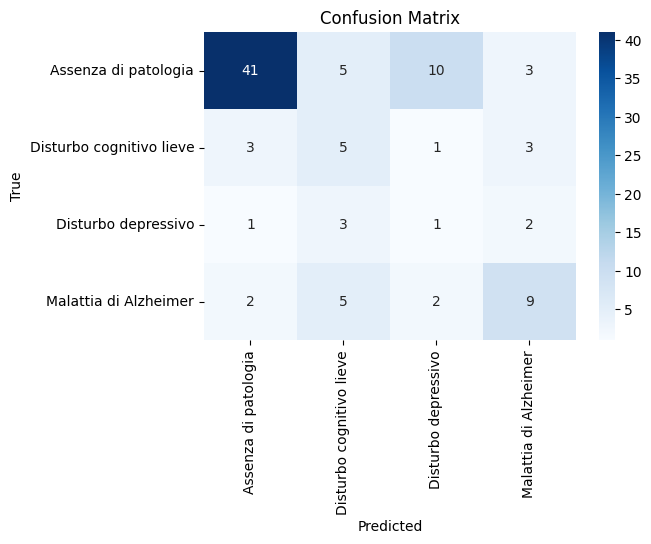

----------------------------------------------------------------------------------------------------

=== Addestramento modello: DecisionTree ===
Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5137
f1_macro: 0.4719

Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 15}

=== Test set scores ===
Balanced Accuracy: 0.4633
F1 Score (macro): 0.4686
ROC AUC: 0.7099

Classification report:
                           precision    recall  f1-score   support

    Assenza di patologia       0.84      0.63      0.72        59
Disturbo cognitivo lieve       0.31      0.42      0.36        12
     Disturbo depressivo       0.05      0.14      0.07         7
   Malattia di Alzheimer       0.80      0.67      0.73        18

                accuracy                           0.57        96
               macro avg       0.50      

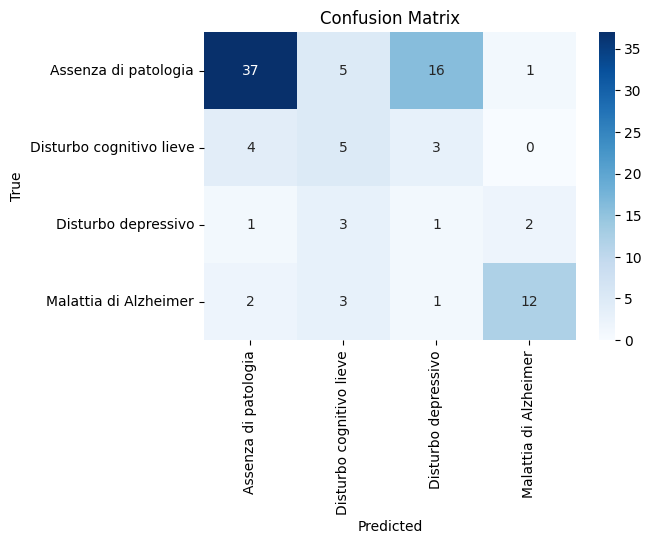

----------------------------------------------------------------------------------------------------

=== Addestramento modello: BalancedRandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5241
f1_macro: 0.5298

Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}

=== Test set scores ===
Balanced Accuracy: 0.5217
F1 Score (macro): 0.5120
ROC AUC: 0.7537

Classification report:
                           precision    recall  f1-score   support

    Assenza di patologia       0.86      0.86      0.86        59
Disturbo cognitivo lieve       0.43      0.50      0.46        12
     Disturbo depressivo       0.00      0.00      0.00         7
   Malattia di Alzheimer       0.72      0.72      0.72        18

                accuracy                           0.73        96
               macro avg       0.50 

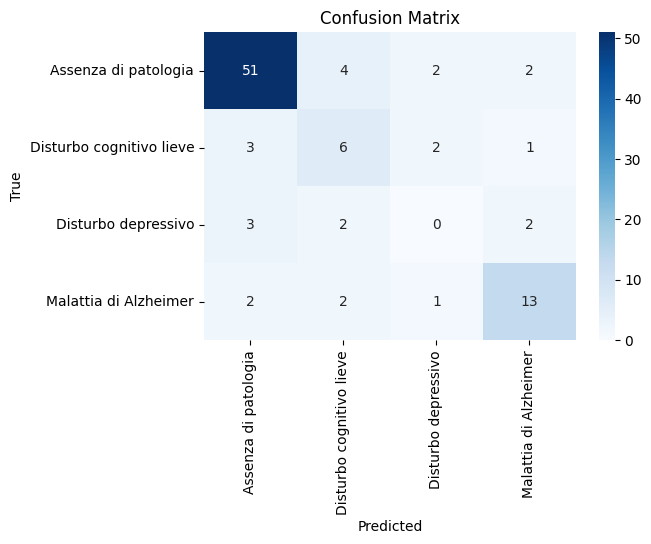

----------------------------------------------------------------------------------------------------

=== Addestramento modello: SVM ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5020
f1_macro: 0.4848

Best parameters: {'classifier__C': 1, 'classifier__degree': 3, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}

=== Test set scores ===
Balanced Accuracy: 0.4567
F1 Score (macro): 0.4449
ROC AUC: 0.7621

Classification report:
                           precision    recall  f1-score   support

    Assenza di patologia       0.86      0.71      0.78        59
Disturbo cognitivo lieve       0.33      0.42      0.37        12
     Disturbo depressivo       0.08      0.14      0.11         7
   Malattia di Alzheimer       0.50      0.56      0.53        18

                accuracy                           0.60        96
               macro avg       0.44      0.46      0.44        96
            weig

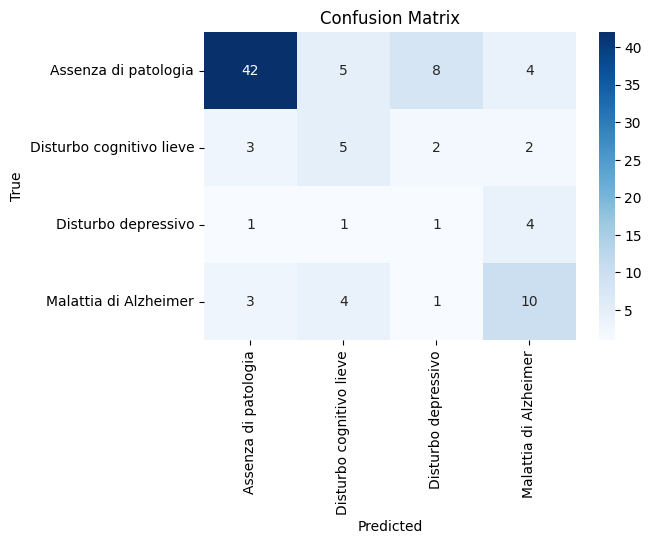

----------------------------------------------------------------------------------------------------

=== Addestramento modello: ExtraTrees ===
Fitting 5 folds for each of 144 candidates, totalling 720 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5176
f1_macro: 0.5164

Best parameters: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 15, 'classifier__n_estimators': 100}

=== Test set scores ===
Balanced Accuracy: 0.4619
F1 Score (macro): 0.4437
ROC AUC: 0.7304

Classification report:
                           precision    recall  f1-score   support

    Assenza di patologia       0.86      0.85      0.85        59
Disturbo cognitivo lieve       0.31      0.33      0.32        12
     Disturbo depressivo       0.00      0.00      0.00         7
   Malattia di Alzheimer       0.55      0.67      0.60        18

                accuracy                           0.69        96
               macro avg       0.43      0.4

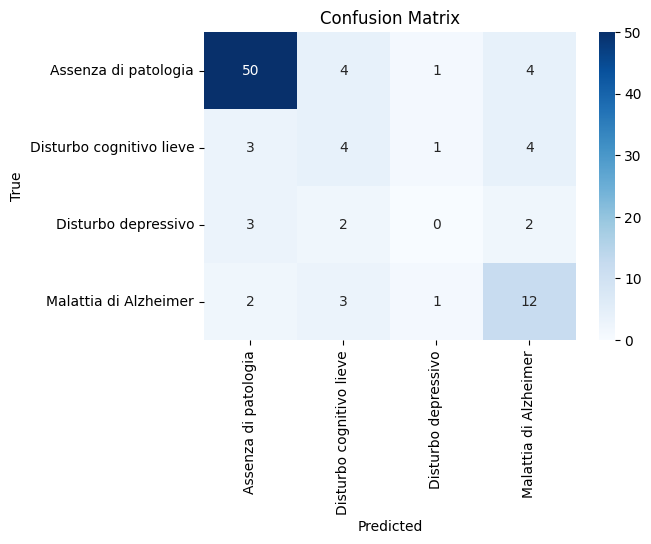

----------------------------------------------------------------------------------------------------

=== Addestramento modello: LGBM ===
Fitting 5 folds for each of 60 candidates, totalling 300 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5573
f1_macro: 0.5679

Best parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': -1, 'classifier__n_estimators': 150}

=== Test set scores ===
Balanced Accuracy: 0.4688
F1 Score (macro): 0.4729
ROC AUC: 0.7703

Classification report:
                           precision    recall  f1-score   support

    Assenza di patologia       0.83      0.85      0.84        59
Disturbo cognitivo lieve       0.36      0.42      0.38        12
     Disturbo depressivo       0.00      0.00      0.00         7
   Malattia di Alzheimer       0.73      0.61      0.67        18

                accuracy                           0.69        96
               macro avg       0.48      0.47      0.47        96
            weighted a

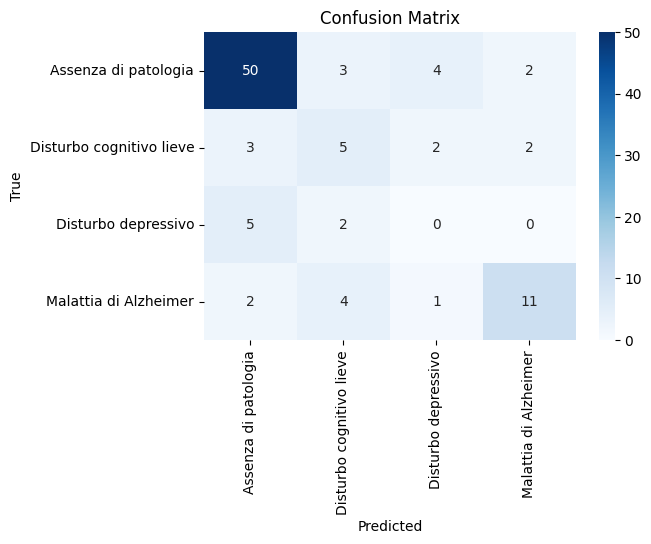

----------------------------------------------------------------------------------------------------

=== Addestramento modello: CatBoost ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5350
f1_macro: 0.5356

Best parameters: {'classifier__depth': 4, 'classifier__iterations': 500, 'classifier__learning_rate': 0.05}

=== Test set scores ===
Balanced Accuracy: 0.4630
F1 Score (macro): 0.4532
ROC AUC: 0.7985

Classification report:
                           precision    recall  f1-score   support

    Assenza di patologia       0.85      0.80      0.82        59
Disturbo cognitivo lieve       0.33      0.50      0.40        12
     Disturbo depressivo       0.00      0.00      0.00         7
   Malattia di Alzheimer       0.62      0.56      0.59        18

                accuracy                           0.66        96
               macro avg       0.45      0.46      0.45        96
            weighted avg   

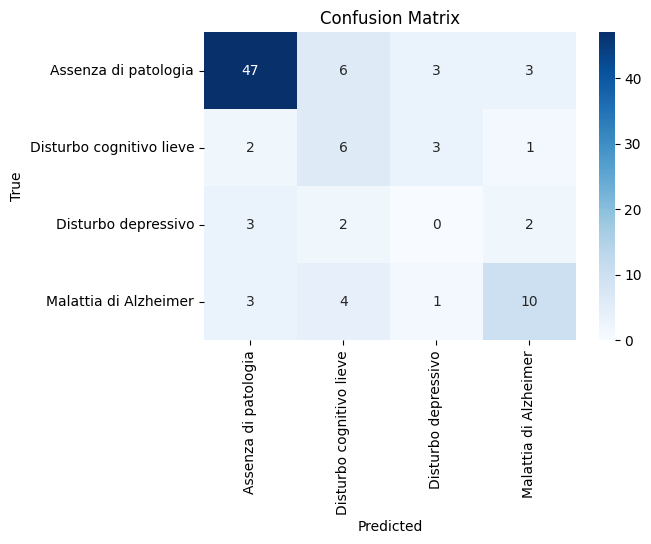

----------------------------------------------------------------------------------------------------

=== Addestramento modello: XGB ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.5653
f1_macro: 0.5793

Best parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 10, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}

=== Test set scores ===
Balanced Accuracy: 0.4773
F1 Score (macro): 0.4763
ROC AUC: 0.7852

Classification report:
                           precision    recall  f1-score   support

    Assenza di patologia       0.88      0.88      0.88        59
Disturbo cognitivo lieve       0.31      0.42      0.36        12
     Disturbo depressivo       0.00      0.00      0.00         7
   Malattia di Alzheimer       0.73      0.61      0.67        18

                accuracy                           0.71        96
               macro 

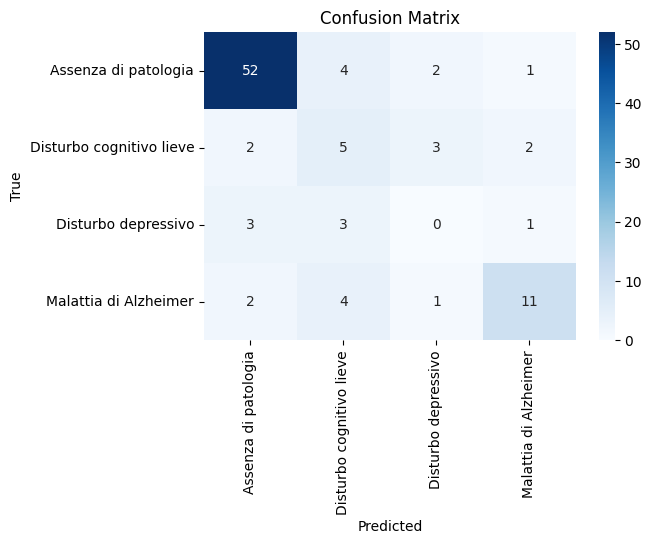

----------------------------------------------------------------------------------------------------


In [ ]:
# Dizionario dei modelli e delle relative griglie di iperparametri da ottimizzare.
# Ogni elemento contiene:
# - 'model': il classificatore (può essere None e definito nel ciclo)
# - 'param_grid': griglia di iperparametri da testare con GridSearchCV
models = {
    'WeightedKNN':{
        'model': KNeighborsClassifier(weights='distance'),
        'param_grid': {
            'classifier__n_neighbors': [3, 5, 7, 9, 11, 13], # Numero di elementi vicini considerati
            'classifier__metric': ['minkowski', 'euclidean', 'manhattan'], # Metrica di distanza utilizzata
            'classifier__p': [1, 2], # utilizzato solo in caso di distanza "minkowski"
        }
    },

    'DecisionTree':{
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'param_grid': {
            'classifier__max_depth': [5, 10, 15, None], # Massima profondità dell'albero
            'classifier__min_samples_split': [5, 10, 15], # Numero minimo di campioni richiesti per dividere un nodo
            'classifier__min_samples_leaf': [2, 4, 8], # Numero minimo di campioni in una foglia (nodo finale)
            'classifier__criterion': ['gini', 'entropy'], # Funzione per valutare la qualità di una divisione
        }
    },

    'BalancedRandomForest':{
        'model': BalancedRandomForestClassifier(random_state=42, replacement=True),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200], # numero di alberi
            'classifier__max_depth': [None, 10, 20, 30], # massima profondità di ogni albero
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
        }
    },

    'SVM':{
        'model': SVC(class_weight='balanced', probability=True, random_state=42),
        'param_grid': {
        'classifier__C': [0.1, 1, 10], # parametro di regolarizzazione
        'classifier__kernel': ['linear', 'rbf', 'poly'], # funzione kernel utilizzata
        'classifier__gamma': ['scale', 'auto'],  # controlla quanto influisce un singolo punto sulla decisione (solo per 'rbf' e 'poly')
        'classifier__degree': [3, 4],  # imposta il grado del polinomio (solo per 'poly')
        }
    },

    'ExtraTrees': {
        'model': ExtraTreesClassifier(random_state=42, class_weight='balanced'),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 150, 200],
            'classifier__max_depth': [None, 5, 10, 15],
            'classifier__min_samples_split': [5, 10, 15],
            'classifier__min_samples_leaf': [1, 2, 4],
        }
    },

    'LGBM':{
        'model': LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 150, 200],
            'classifier__learning_rate':  [0.01, 0.05, 0.1], # parametro che misura quanto ogni nuovo albero corregge  l'errore dei precedenti
            'classifier__max_depth': [-1, 3, 5, 7, 10],
        }
    },

    'CatBoost':{
        'model': None,  # sarà definito nel ciclo
        'param_grid':{
            'classifier__iterations': [300, 500], # numero di alberi
            'classifier__depth': [4, 8],
            'classifier__learning_rate': [0.01, 0.05],
        }
    },

    'XGB':{
        'model': None,  # sarà definito nel ciclo
        'param_grid': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [3, 6, 10],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__subsample': [0.8, 1.0], # Percentuale di dati usati per costruire ogni albero
            'classifier__colsample_bytree': [0.8, 1.0], # Percentuale di feature usate per ogni albero
        }
    }
}

# Metriche di valutazione da usare nella ricerca a griglia
scoring = {
    'balanced_accuracy': make_scorer(balanced_accuracy_score),  # accuracy corretta per classi sbilanciate
    'f1_macro': make_scorer(f1_score, average='macro')    # media semplice degli F1 di ogni classe
}

# Strategia di validazione incrociata: StratifiedKFold mantiene la distribuzione delle classi in ogni fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5 split -> a turno, 4 sono usati per l'addestramento e 1 per la validazione

# Ciclo di addestramento per ogni modello
for name, m in models.items():
    print(f"\n=== Addestramento modello: {name} ===")

    # Inizializzazione dinamica dei modelli in base al tipo di problema (binario o multiclasse)
    if name == 'XGB': # XGBoost richiede un parametro (objective) diverso per problemi binari e multiclasse
        if is_multiclass:
            model = XGBClassifier(
                objective='multi:softprob',
                num_class=len(np.unique(y_train)),
                eval_metric='mlogloss',
                random_state=42
            )
        else:
            model = XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=42
            )
    elif name == 'CatBoost': # CatBoost richiede che il parametro loss_function sia fissato a 'Multiclass' per problemi multiclasse e a 'Logloss' per problemi binari
        model = CatBoostClassifier(
            loss_function='MultiClass' if is_multiclass else 'Logloss',
            random_seed=42,
            verbose=0
        )
    else:
        model = m['model']

    # Pipeline ottenuta combinando preprocessing e classificatore
    pipeline = build_pipeline(model)

    # Ricerca a griglia con validazione incrociata
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=m['param_grid'],
        scoring=scoring,
        refit='balanced_accuracy', # la metrica da ottimizzare per scegliere il miglior modello
        cv=cv,
        n_jobs=-1,
        verbose=2,
        return_train_score=True,
        error_score='raise'
    )

    # XGBoost richiede etichette numeriche, quindi si applica LabelEncoder
    if name == 'XGB':
        le = LabelEncoder()
        y_train_encoded = le.fit_transform(y_train) # da stringa a numeri interi
        y_test_encoded = le.transform(y_test)

        search.fit(X_train, y_train_encoded)

        class_labels = le.classes_
        evaluate_model(search, X_test, y_test, class_labels, le=le, is_multiclass=is_multiclass)

    else:
        # Esegue la ricerca a griglia con validazione incrociata:
        # per ogni combinazione di iperparametri, la pipeline viene
        # addestrata e valutata sui fold definiti da StratifiedKFold.
        # Per ogni fold, la pipeline è fittata solo sul fold di training è la trasformazione è applicata al fold di validazione
        search.fit(X_train, y_train)
        # Recupera le classi target dal miglior modello trovato
        class_labels = search.best_estimator_.named_steps['classifier'].classes_
        evaluate_model(search, X_test, y_test, class_labels, is_multiclass=is_multiclass) # Valuta il modello ottimizzato sul test set non visto

    print("-"*100)
